In [ ]:

# STEP 1: IMPORT LIBRARIES

# Libraries are tools that help us perform data analysis
# and machine learning tasks.

import pandas as pd          # Used for working with datasets (tables)
import numpy as np           # Used for numerical calculations
import matplotlib.pyplot as plt   # Used for creating graphs

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split   # Splits dataset into training and testing
from sklearn.preprocessing import LabelEncoder         # Converts text data into numbers
from sklearn.linear_model import LinearRegression      # Machine learning model used for prediction
from sklearn.metrics import mean_squared_error, r2_score   # Used to evaluate model performance

In [ ]:

# STEP 2: LOAD DATASET

# Read the student performance dataset from CSV file.

data = pd.read_csv("Sales_Dataset_2025.csv")

# Display first 5 rows to understand the dataset structure
print("First 5 rows of dataset:")
print(data.head().T)

First 5 rows of dataset:
                          0         1         2         3         4
Month              Jan-2025  Jan-2025  Jan-2025  Jan-2025  Feb-2025
Region                North     South      East      West     North
Sales                 52000     45000     48000     50000     60000
Advertising_Spend      8000      7000      7500      8200      9000
Profit                12000     10000     11000     11500     15000


In [ ]:

# STEP 3: DATA UNDERSTANDING

# Check basic information about the dataset.

# Check number of rows and columns
print("Dataset shape:")
print(data.shape)

# Check column names and data types
print("\nDataset information:")
print(data.info())

# Statistical summary of numeric columns
print("\nStatistical summary:")
print(data.describe())

# Check missing values in each column
print("\nMissing values in dataset:")
print(data.isnull().sum())

Dataset shape:
(24, 5)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
Month                24 non-null object
Region               24 non-null object
Sales                24 non-null int64
Advertising_Spend    24 non-null int64
Profit               24 non-null int64
dtypes: int64(3), object(2)
memory usage: 1.0+ KB
None

Statistical summary:
              Sales  Advertising_Spend        Profit
count     24.000000          24.000000     24.000000
mean   62041.666667        9100.000000  15916.666667
std     8685.215657        1072.177792   3377.246971
min    45000.000000        7000.000000  10000.000000
25%    56250.000000        8200.000000  13375.000000
50%    62500.000000        9100.000000  15750.000000
75%    69250.000000        9850.000000  18250.000000
max    75000.000000       11000.000000  22000.000000

Missing values in dataset:
Month                0
Region               0
Sales                0
Adver

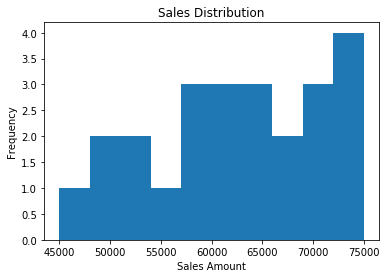

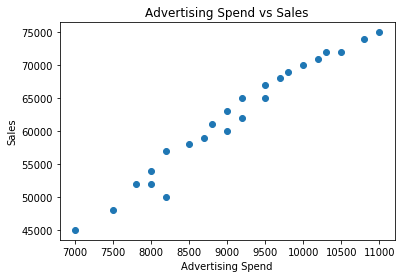

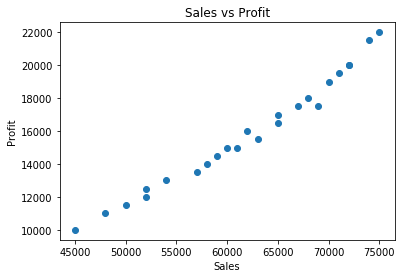

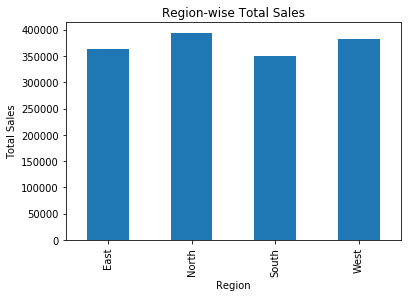

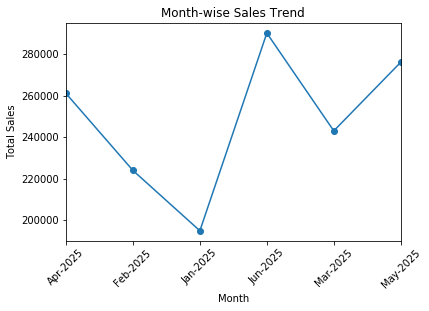

In [ ]:

# STEP 4: DATA VISUALIZATION


# 1. Sales Distribution
plt.figure()
plt.hist(data['Sales'], bins=10)
plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()


# 2. Advertising Spend vs Sales
plt.figure()
plt.scatter(data['Advertising_Spend'], data['Sales'])
plt.title("Advertising Spend vs Sales")
plt.xlabel("Advertising Spend")
plt.ylabel("Sales")
plt.show()


# 3. Sales vs Profit
plt.figure()
plt.scatter(data['Sales'], data['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()


# 4. Region-wise Total Sales (Bar Chart)
plt.figure()
data.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Region-wise Total Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


# 5. Month-wise Sales Trend (VERY IMPORTANT 🔥)
plt.figure()
data.groupby('Month')['Sales'].sum().plot(kind='line', marker='o')
plt.title("Month-wise Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [ ]:

# STEP 5: DATA PREPARATION (Sales Dataset 2025)




# Create encoder object
encoder = LabelEncoder()

# Convert categorical columns into numeric
data['Month'] = encoder.fit_transform(data['Month'])
data['Region'] = encoder.fit_transform(data['Region'])

# Display updated dataset
print("Dataset after converting categorical values:\n")
print(data.head(7))

Dataset after converting categorical values:

   Month  Region  Sales  Advertising_Spend  Profit
0      2       1  52000               8000   12000
1      2       2  45000               7000   10000
2      2       0  48000               7500   11000
3      2       3  50000               8200   11500
4      1       1  60000               9000   15000
5      1       2  52000               7800   12500
6      1       0  54000               8000   13000


In [ ]:

# STEP 6: REMOVE UNNECESSARY COLUMN

# In this dataset, no unnecessary column like ID is present
# So we skip this step

print("Columns in dataset:")
print(data.columns)



# STEP 7: DEFINE FEATURES AND TARGET


# X = input features
X = data.drop('Profit', axis=1)

# y = target variable (Profit)
y = data['Profit']



# STEP 8: TRAIN-TEST SPLIT




X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)



# STEP 9: MODEL TRAINING



model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model training completed.")



# STEP 10: PREDICT RESULTS


y_pred = model.predict(X_test)

print("\nSample Predicted Profit Values:")
print(y_pred[:10])



# STEP 11: MODEL EVALUATION


from sklearn.metrics import mean_squared_error, r2_score

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

Columns in dataset:
Index(['Month', 'Region', 'Sales', 'Advertising_Spend', 'Profit'], dtype='object')
Training data size: (19, 4)
Testing data size: (5, 4)
Model training completed.

Sample Predicted Profit Values:
[ 17210.83433689  20179.43274364  12332.19582664  18129.24471836
  16087.78153658]

Mean Squared Error: 42282.2179452
R2 Score: 0.993994003133
